# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.
Además importaremos requests, lo necesitaremos para hacer una llamada a una API


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests


## 2. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

El dataset que vamos a cargar tiene la informacion de 35.000 partidas del juego Crash en el casino 1xBet

También cambiamos el formato en el que se mostrarán los números porque hay algunas cantidades muy elevadas que se mostrarían mal por defecto. (Notación científica)

In [3]:
# Change this path to point to your data file
file_path = '../data/raw/1xBet35kGameRecords.csv'
df = pd.read_csv(file_path)

# Cambiamos el formato porque en caso de no hacerlo, hay números demasiado grandes que se representarían en notación científica
pd.options.display.float_format = '{:.2f}'.format



## 2.5. Realizamos una conversión de EGP a EUR
El dataset tiene la moneda de Egipto y por ello necesitamos realizar ahora una conversión para poder ver los datos de una manera que podamos entender.
Para ello utilizaremos una API pública, sin KEY, pero con limite de uso.

In [4]:
# Obtener la tasa de cambio actual (EGP a EUR) una sola vez (Para no hacer muchas peticiones a la API)
# Importante saber que esta API es gratis y sin KEY pero solo se puede hacer una peticion cada 20 minutos mas o menos
url = "https://open.er-api.com/v6/latest/EGP"
try:
    response = requests.get(url)
    response.raise_for_status()
    data = response.json()
    
    # Extraemos la tasa específica para EUR
    egp_to_eur_rate = data["rates"]["EUR"]
except Exception as e:
    raise Exception(f"No se pudo obtener la tasa de cambio de la API: {e}")

# Se definen las columnas que queremos convertir (Las que son de dinero unicamente)
columnas_a_convertir = [
    'Total Bets', 
    'Total Winnings', 
    'Casino Earnings', 
    'Casino Cumulative Earnings'
]

# Asegurarse de que los datos sean numéricos y multiplicar por la tasa
# (Uso pd.to_numeric por si acaso había strings o datos mal formateados)
for col in columnas_a_convertir:
    df[col] = pd.to_numeric(df[col], errors='coerce') * egp_to_eur_rate

# Redondeo de los resultados a 2 decimales:
df[columnas_a_convertir] = df[columnas_a_convertir].round(2)

## 3. Visualizacion inicial del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [5]:
df.head(10)
# Print the converted DataFrame
#print(df)

,Game ID,Total Bets,Total Winnings,Total Players,Players Lost,Odds,Casino Earnings,Timestamp,Casino Cumulative Earnings
0,1,15191.43,20018.14,10798,4747,3.61,-4826.70,"4/11/2024, 1:21:03 PM",-4665.03
1,2,15524.24,12838.29,11639,6486,2.64,2685.96,"4/11/2024, 1:21:26 PM",-9491.73
2,3,13458.46,42712.76,11060,1012,8.30,-29254.29,"4/11/2024, 1:21:59 PM",-6805.77
3,4,11956.84,44870.10,10918,578,20.36,-32913.26,"4/11/2024, 1:22:42 PM",-36060.06
4,5,10378.52,1252.69,10086,9099,1.45,9125.82,"4/11/2024, 1:23:02 PM",-68973.33
5,6,9739.11,8367.76,8470,4631,2.71,1371.34,"4/11/2024, 1:23:26 PM",-59847.51
6,7,13067.50,15552.15,10322,4712,2.81,-2484.65,"4/11/2024, 1:23:50 PM",-58476.16
7,8,3246.21,373.04,10341,10062,1.16,2873.17,"4/11/2024, 1:24:08 PM",-60960.81
8,9,11797.33,658.83,9172,8636,1.26,11138.50,"4/11/2024, 1:24:27 PM",-58087.64
9,10,12926.27,14815.37,9161,4724,3.01,-1889.10,"4/11/2024, 1:24:52 PM",-46949.14


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [6]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 34863 entries, 0 to 34862
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Game ID                     34863 non-null  int64  
 1   Total Bets                  34863 non-null  float64
 2   Total Winnings              34863 non-null  float64
 3   Total Players               34863 non-null  int64  
 4   Players Lost                34863 non-null  int64  
 5   Odds                        34863 non-null  float64
 6   Casino Earnings             34863 non-null  float64
 7   Timestamp                   34863 non-null  str    
 8   Casino Cumulative Earnings  34863 non-null  float64
dtypes: float64(5), int64(3), str(1)
memory usage: 2.4 MB
Número de filas: 34863
Número de columnas: 9


## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [7]:
# Numerical variables
df.describe()

# Categorical values (Example for a columnn)
#df['Timestamp'].value_counts()

,Game ID,Total Bets,Total Winnings,Total Players,Players Lost,Odds,Casino Earnings,Casino Cumulative Earnings
count,34863.00,34863.00,34863.00,34863.00,34863.00,34863.00,34863.00,34863.00
mean,17432.00,10270.61,9913.05,7911.47,4974.47,4.10,357.56,6513370.65
std,10064.23,3002.43,11898.49,2426.98,3464.11,5.59,11939.68,3569286.71
min,1.00,-991.08,0.00,0.00,0.00,0.00,-66075.21,-517986.86
25%,8716.50,8169.68,978.35,6039.50,1943.00,1.30,-6476.41,3663761.75
50%,17432.00,9966.97,4223.82,7715.00,4614.00,1.95,5132.37,6074172.38
75%,26147.50,11952.94,16158.83,10125.50,7431.00,3.90,8790.46,9273714.54
max,34863.00,28713.49,88136.20,19426.00,18701.00,34.99,26913.37,12733351.64


## 6. Inspección de limpieza del dataset
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [ ]:
# Valores nulos
#df.isnull().sum()
print('Valores Nulos: ',df.isnull().sum().sum())

# Valores duplicados
#df.duplicated().sum()
print('Valores Duplicados: ',df.duplicated().sum())

# Registros con Total Bets = 0
zero_rows = df[df['Total Bets'] == 0]
print('Filas con Total Bets = 0: ', zero_rows.shape[0])

# Registros con Total Bets & Total Winnings = 0
zero_rows = df[(df['Total Bets'] == 0) & (df['Total Winnings'] == 0)]
print('Filas con Total Bets y Total Winnings = 0: ', zero_rows.shape[0])



Valores Nulos:  0
Valores Duplicados:  0
Filas con Total Bets = 0:  15
Filas con Total Bets y Total Winnings = 0:  1
Shape: (34863, 9)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 34863 entries, 0 to 34862
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Game ID                     34863 non-null  int64  
 1   Total Bets                  34863 non-null  float64
 2   Total Winnings              34863 non-null  float64
 3   Total Players               34863 non-null  int64  
 4   Players Lost                34863 non-null  int64  
 5   Odds                        34863 non-null  float64
 6   Casino Earnings             34863 non-null  float64
 7   Timestamp                   34863 non-null  str    
 8   Casino Cumulative Earnings  34863 non-null  float64
dtypes: float64(5), int64(3), str(1)
memory usage: 2.4 MB


## 7. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

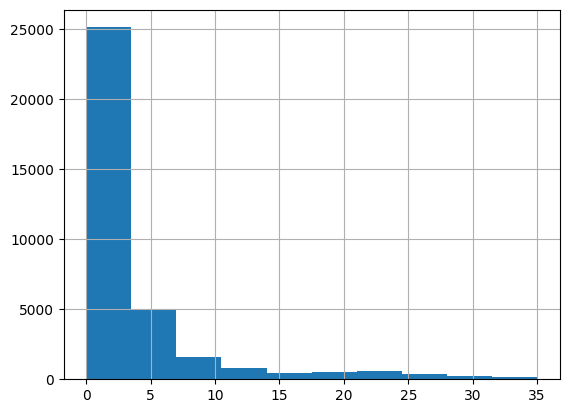

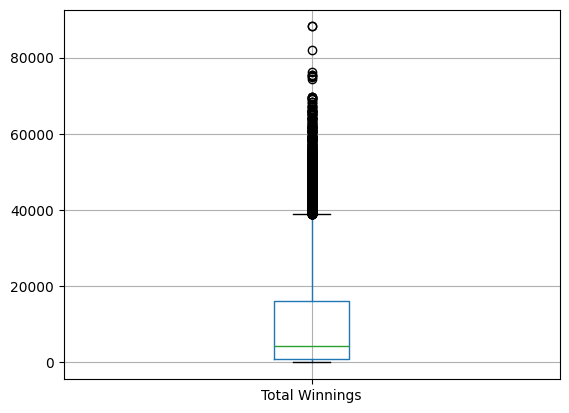

In [29]:
# Histogram for a numerical variable
df['Odds'].hist()
plt.show()

# Boxplot
df.boxplot(column='Total Winnings')
plt.show()

## 8. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11916\3041515580.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


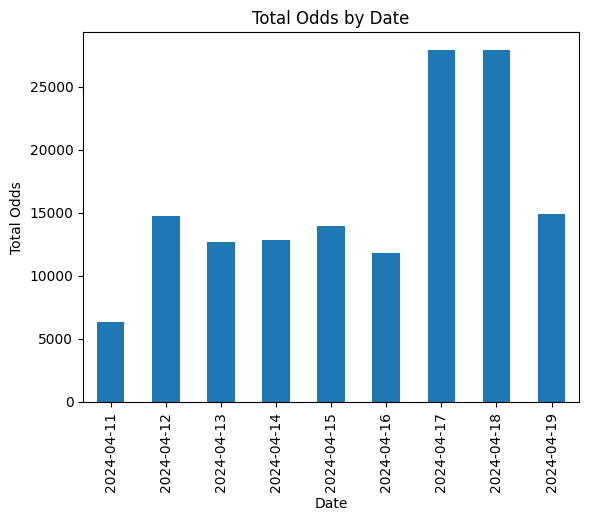

In [ ]:
# Bar plot for a categorical variable
# Necesito agrupar por dia y sumar las apuestas ya que con la cantidad de datos, y el tipo de columna que es el Timestamp (La unica categorica que tengo en el dataset) tarda demasiado en procesar al ser todas diferentes
# Conversion de"Timestamp" a datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# Agrupacion por dia
grouped_data = df.groupby(df['Timestamp'].dt.date)['Odds'].sum()

# Creacion del bar plot
grouped_data.plot(kind='bar')
plt.xlabel('Date')
plt.ylabel('Total Odds')
plt.title('Total Odds by Date')
plt.show()

#df['Timestamp'].value_counts().plot(kind='bar')
#plt.show()

## 9. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

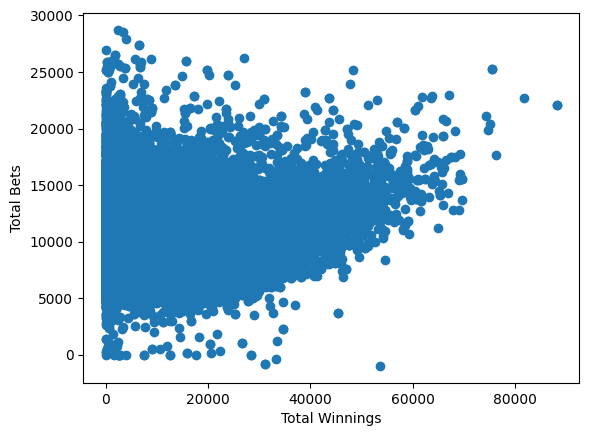

In [35]:
# Scatterplot
plt.scatter(df['Total Winnings'], df['Total Bets'])
plt.xlabel('Total Winnings')
plt.ylabel('Total Bets')
plt.show()


# Crosstab for two categorical variables   
#pd.crosstab(df['Game ID'], df['Total Bets'])

## 10. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

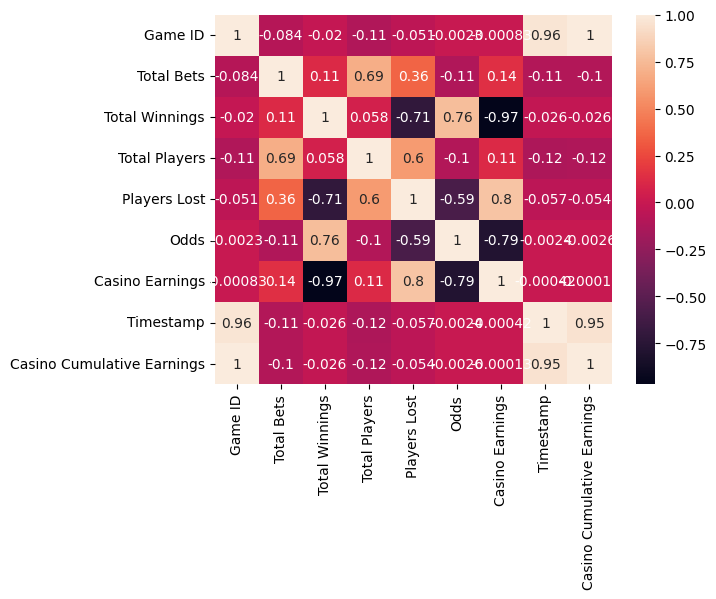

In [36]:
# Correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()